# Week-1

Contents:

[1. Advanced Linear Algebra](#1.-Advanced-Linear-Algebra)

* [1.1. Singular Value Decomposition (SVD)](#1.1.-Singular-Value-Decomposition-(SVD))

* [1.2. Condition Number](#1.2.-Condition-Number)

* [1.3. The Moore-Penrose Pseudoinverse](#1.3.-The-Moore-Penrose-Pseudoinverse)

* [1.4. Least Squares System](#1.4.-Least-Squares-System)

[2. Vector-Matrix Gradients](#2.-Vector-Matrix-Gradients)

* [2.1. Gradient with Respect to a Vector](#2.1.-Gradient-with-Respect-to-a-Vector)

* [2.2. Gradient with Respect to a Matrix](#2.2.-Gradient-with-Respect-to-a-Matrix)

* [2.3. Hessian Matrix](#2.3.-Hessian-Matrix)

[3. Gradient Flow](#3.-Gradient-Flow)

---

In [192]:
import numpy as np
from scipy import linalg
from scipy.linalg import pinv
from scipy.linalg import lstsq

---

## 1. Advanced Linear Algebra

Linear algebra is a branch of mathematics that is widely used throughout science and engineering.                                                

A good understanding of linear algebra is essential for understanding and working
with many machine learning and deep learning algorithms.                             
            
We therefore precede our introduction to deep learning with a focused presentation of the key linear algebra prerequisites.

---

### 1.1. Singular Value Decomposition (SVD)

The SVD provides a way to factorize a matrix, into singular vectors and singular values.                                         

Every real matrix has a SVD.

We can write a matrix A as a product of three matrices:

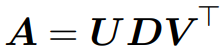

Suppose A is an m×n matrix. Then U is defined to be an m×m, D an m×n , and V an n×n matrix.

The matrices U and V are both defined to be orthogonal matrices.                                            
The matrix D is defined to be a diagonal matrix (not necessarily square).

The elements along the diagonal of D are known as the singular values of the matrix A.                                         
The columns of U are known as the left-singular vectors and columns of V are known as the right-singular vectors.

In [193]:
A = np.array([[18, -9, 3, -2],
              [-4, 15, 6, 25],
              [1, -8, 12, -7]])

print(f'A:\n{A}')

A:
[[18 -9  3 -2]
 [-4 15  6 25]
 [ 1 -8 12 -7]]


In [194]:
U, s, Vt = linalg.svd(A)

In [195]:
print(f'U:\n{U}')
print(f'\nSingular values:\n{s}')
print(f'\nVt:\n{Vt}')

U:
[[ 0.37767695 -0.85883285 -0.34607263]
 [-0.87451582 -0.45367142  0.17147688]
 [ 0.30427324 -0.23788312  0.92240415]]

Singular values:
[32.92715826 18.18042883 12.77788153]

Vt:
[[ 0.32193855 -0.57554362 -0.01405482 -0.75160334]
 [-0.76357873  0.15552379 -0.44845612 -0.43777504]
 [-0.46899876 -0.13244969  0.86551853 -0.11564999]
 [-0.30552129 -0.7918453  -0.22263704  0.47965666]]


In [196]:
D = np.zeros((U.shape[0], Vt.shape[0]))

D[:len(s), :len(s)] = np.diag(s)

print(f'D:\n{D}')

D:
[[32.92715826  0.          0.          0.        ]
 [ 0.         18.18042883  0.          0.        ]
 [ 0.          0.         12.77788153  0.        ]]


In [197]:
A_svd = U @ D @ Vt

print(f'A:\n{A}')
print(f'\nA_svd:\n{A_svd}')

A:
[[18 -9  3 -2]
 [-4 15  6 25]
 [ 1 -8 12 -7]]

A_svd:
[[18. -9.  3. -2.]
 [-4. 15.  6. 25.]
 [ 1. -8. 12. -7.]]


---

### 1.2. Condition Number

The condition number of a matrix measures how sensitive a linear system is to small changes in the input.

For a matrix A, it tells you how much errors in b or numerical rounding can be amplified when solving:

Ax = b

We can use SVD of A and define condition number as follows:

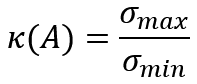

where:

σ max = largest singular value                                                          
σ min = smallest nonzero singular value

In [198]:
print(f'A:\n{A}')

A:
[[18 -9  3 -2]
 [-4 15  6 25]
 [ 1 -8 12 -7]]


In [199]:
print(f'Singular values:\n{s}')

Singular values:
[32.92715826 18.18042883 12.77788153]


In [200]:
cond_num = s[0] / s[-1]
print(f'condition number = {cond_num}')

condition number = 2.5768871142558845


confirm the solution

In [201]:
cond = np.linalg.cond(A)
print(f'condition number = {cond}')

condition number = 2.5768871142558845


---

### 1.3. The Moore-Penrose Pseudoinverse

Matrix inversion is not defined for matrices that are not square or singular. so the Moore-Penrose pseudoinverse allows us to make some headway in
this case.

The pseudoinverse of A is defined as a matrix

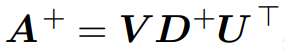

Where U, D and V are the singular value decomposition of A.                                               
The pseudoinverse D+ of a diagonal matrix D is obtained by taking the reciprocal of its non-zero elements then taking the transpose of the resulting matrix.

In [202]:
print(f'A:\n{A}')

A:
[[18 -9  3 -2]
 [-4 15  6 25]
 [ 1 -8 12 -7]]


In [203]:
V = Vt.T
print(f'V:\n{V}')

V:
[[ 0.32193855 -0.76357873 -0.46899876 -0.30552129]
 [-0.57554362  0.15552379 -0.13244969 -0.7918453 ]
 [-0.01405482 -0.44845612  0.86551853 -0.22263704]
 [-0.75160334 -0.43777504 -0.11564999  0.47965666]]


In [204]:
Ut = U.T
print(f'Ut:\n{Ut}')

Ut:
[[ 0.37767695 -0.87451582  0.30427324]
 [-0.85883285 -0.45367142 -0.23788312]
 [-0.34607263  0.17147688  0.92240415]]


In [205]:
D_plus = np.zeros((V.shape[0], Ut.shape[0]))

D_plus[:len(s), :len(s)] = np.diag(1/s)

print(f'D_plus:\n{D_plus}')

D_plus:
[[0.03037007 0.         0.        ]
 [0.         0.0550042  0.        ]
 [0.         0.         0.07826023]
 [0.         0.         0.        ]]


In [206]:
A_plus = V @ D_plus @ Ut

print(f'A_plus:\n{A_plus}')

A_plus:
[[ 0.05246591  0.00420994 -0.02088981]
 [-0.01036115  0.00962756 -0.01691467]
 [-0.00241787  0.02317909  0.06821765]
 [ 0.01519152  0.02933408 -0.00956581]]


Confirm the solution

In [207]:
A_pinv = pinv(A)

print(A_pinv)

[[ 0.05246591  0.00420994 -0.02088981]
 [-0.01036115  0.00962756 -0.01691467]
 [-0.00241787  0.02317909  0.06821765]
 [ 0.01519152  0.02933408 -0.00956581]]


---

### 1.4. Least Squares System

Suppose we want to find the value of x that minimizes

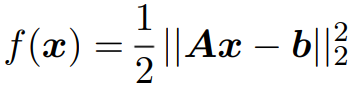

There are specialized linear algebra algorithms that can solve this problem efficiently.                          
However, we can use the Moore-Penrose pseudoinverse:

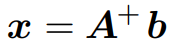

Now we want to find the least squares solution for the following system:

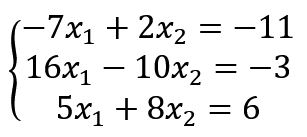

In [208]:
A = np.array([
    [-7, 2],
    [16, -10],
    [5, 8]
])

b = np.array([-11, -3, 6])

print(f"A:\n{A}")
print(f"\nb: {b}")

A:
[[ -7   2]
 [ 16 -10]
 [  5   8]]

b: [-11  -3   6]


In [209]:
x = pinv(A) @ b

print(f"x: {x}")

x: [0.46462491 0.70392701]


confirm the soultion

In [210]:
x_lstsq = lstsq(A, b)

print(f"x_lstsq: {x_lstsq[0]}")

x_lstsq: [0.46462491 0.70392701]


---

## 2. Vector-Matrix Gradients

Most deep learning algorithms involve optimization of some sort, the task of either minimizing or maximizing some function f(x) by altering
x.                                                                                           

The function we want to minimize or maximize is called the **objective function**, a function combining of a one or some loss functions and some terms.

We often denote the value that minimizes or maximizes a function with a superscript ∗ 
                                                   
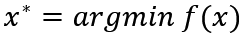

Suppose we have a function y = f(x), where both x and y are real numbers.
The **derivative** of this function is denoted as f'(x) or as dy/dx.                                              
It is useful for minimizing a function because it tells us how to change x in order to make a small improvement in y

We can reduce f(x) by moving x in small steps with opposite sign of the derivative.
This technique is called **gradient descent**.

Points where f'(x) = 0 are known as **critical points**.                                 
                                                    
A **local minimum** is a point where f(x) is lower than at all neighboring points.                                           
Some critical points are neither maxima nor minima. These are known as **saddle points**.                                      
A point that obtains the absolute lowest value of f(x) is a **global minimum**.

---

### 2.1 Gradient with Respect to a Vector

For functions with multiple inputs, we must make use of the concept of **partial derivatives**.                           

The partial derivative **∂f(x) / ∂xi** measures how f changes as only the variable xi increases at point x.                                           

The **gradient** generalizes the notion of derivative to the case where the derivative is with respect to a vector: the gradient of f is the
vector containing all of the partial derivatives, denoted **∇f(x)**.                                         

Element i of the gradient is the partial derivative of f with respect to xi. In multiple dimensions, critical points are points where every element of the gradient is equal to zero.

Example) consider the following function:

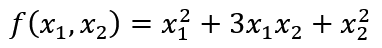

In [211]:
def f(x):
    return x[0]**2 + 3*x[0]*x[1] + x[1]**2

In [212]:
x = [2.0, 5.0]
f(x)

59.0

The gradient is

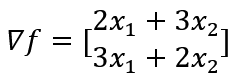

Analytical Gradient

In [213]:
def grad_anlytc(x):
    return np.array([
        2*x[0] + 3*x[1],
        3*x[0] + 2*x[1]
    ])

In [214]:
print("Analytical:\n",grad_anlytc(x))

Analytical:
 [19. 16.]


Numerical Gradient

For the i-th component:

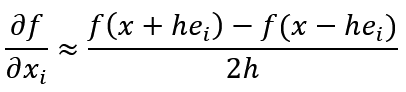

Where h ≈ 1e−5 and ei is the i-th standard basis vector (e.g. e3 = [0,0,1,0])

In [215]:
def grad_num(x, h=1e-5):
    
    g = np.zeros_like(x)
    for i in range(len(x)):
        x1 = x.copy()
        x2 = x.copy()
        x1[i] += h
        x2[i] -= h
        g[i] = (f(x1)-f(x2))/(2*h)

    return g

In [216]:
print("Numerical:\n",grad_num(x))

Numerical:
 [19. 16.]


---

### 2.2. Gradient with Respect to a Matrix

Consider

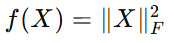

where

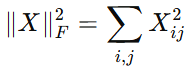

In [217]:
X = np.array([
    [7., 2.],
    [4., 6.]
])

print('X:\n',X)

X:
 [[7. 2.]
 [4. 6.]]


In [218]:
def f(X):
    return np.sum(X**2)

print(f(X))

105.0


Analytical Gradient is as follows:

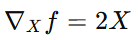

In [219]:
def grad_analytic(X):
    return 2 * X

print("Analytical:\n",grad_analytic(X))

Analytical:
 [[14.  4.]
 [ 8. 12.]]


Numerical Gradient is similar as we saw before:

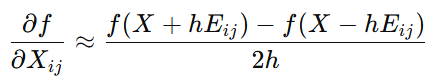

where:                                      

Eij is a matrix of the same size as X that contains a 1 at position (i,j) and 0 elsewhere.

In [ ]:
def grad_numeric(X, h=1e-5):
    
    G = np.zeros_like(X)
    
    for i in range(X.shape[0]):
        for j in range(X.shape[1]):
            X_plus = X.copy()
            X_minus = X.copy()
    
            X_plus[i, j] += h
            X_minus[i, j] -= h
            
            G[i, j] = (f(X_plus) - f(X_minus)) / (2 * h)

    return G

print("Numerical:\n",grad_numeric(X))

Numerical:
 [[14.  4.]
 [ 8. 12.]]


---

### 2.3. Hessian Matrix

When our function has multiple input dimensions, there are many second derivatives.                                     

These derivatives can be collected together into a matrix called the **Hessian matrix**.                                        

The Hessian matrix is defined such that

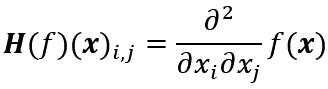

The second derivative can be used to determine whether a critical point is a local maximum, a local minimum, or saddle point.                                                     

When the second derivative f"(x) > 0, the first derivative f'(x) increases as we move to the right and decreases as we move to the left.

Thus, when f'(x) = 0 and f"(x) > 0, we can conclude that x is a local minimum.                                                                
This is known as the **second derivative test**.                                       
However, when f"(x) = 0, the test is inconclusive. In this case x may be a saddle point, or a part of a flat region.

The Hessian plays the role of the second derivative to classify a critical point.

If ∇f(x) = 0 (a critical point):

Positive Definite Hessian (λi>0 for all eigenvalues) ⇒ local minimum.                                  
Negative Definite Hessian (λi<0 for all eigenvalues) ⇒ local maximum.                                         
Indefinite Hessian (has both positive and negative eigenvalues) ⇒ saddle point.                                
singular or semidefinite Hessian  ⇒ test is inconclusive.                                        

Suppose we have the following function:

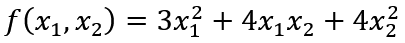

The gradient is

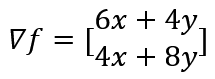

and

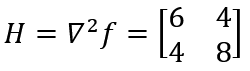

In [221]:
H = np.array([
    [6, 4],
    [4, 8]
])

Now we compute the eigenvalues of H

In [222]:
eigenvalues = np.linalg.eigvals(H)
print(eigenvalues)

[ 2.87689437 11.12310563]


So H is Positive Definite and if x∗ is a critical point of the function then it is a local minimum.

---

## 3. Gradient Flow

Gradient Flow is the continuous-time version of Gradient Descent.

Suppose we want to minimize a function f(x).

In gradient descent, we update the parameter according to

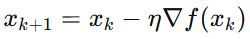

where                                          
η is the learning rate (step size)

If we take smaller and smaller steps (η→0),                                                
Then the discrete update rule becomes a continuous differential equation:

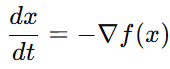

This equation is called the **gradient flow** of f.

Example)

Consider the following function:

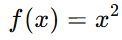

Its gradient is

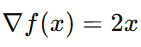

The gradient flow equation becomes

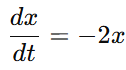

The solution is

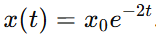

As t → ∞

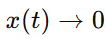

which is exactly the minimum of f(x).